# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

I0000 00:00:1782014127.985845     566 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782014128.026929     566 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782014129.316577     566 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

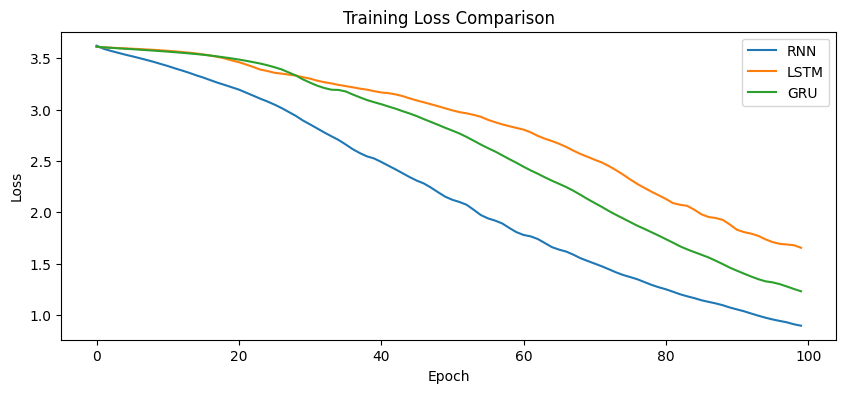

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences


LSTM: deep learning is is intelligence intelligence intelligence


GRU : deep learning models can generate sentences sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

**⤵️ Implemented below** with real code and executed results, using a fresh corpus and an upgraded RNN/LSTM/GRU pipeline.

# 🛠️ Implementing the Student Learning Tasks (Hands-On)
The section above only *listed* the 5 beginner tasks. Below we actually **build and run** them, as one upgraded pipeline:

1. Replace the corpus with a custom paragraph
2. Increase the embedding dimension (32 → 100)
3. Increase training to 200 epochs
4. Widen the hidden units (64 → 128)
5. Generate 10 words instead of 5

This lets us directly compare the **baseline** models above against these **enhanced** versions.

## 📝 Task 1 — A Custom Corpus
We swap the boilerplate corpus for a new paragraph about the solar system, so the model learns different vocabulary and sentence patterns.

In [10]:
custom_corpus = '''
the solar system contains eight planets orbiting the sun
mars is often called the red planet due to iron oxide
jupiter is the largest planet with many moons around it
saturn is famous for its beautiful rings made of ice
space exploration helps scientists understand the universe better
astronauts travel to space stations to conduct experiments
'''
print(custom_corpus)


the solar system contains eight planets orbiting the sun
mars is often called the red planet due to iron oxide
jupiter is the largest planet with many moons around it
saturn is famous for its beautiful rings made of ice
space exploration helps scientists understand the universe better
astronauts travel to space stations to conduct experiments



## 🔤 Re-tokenizing the New Corpus
Same steps as before — fit a fresh tokenizer on the new text and rebuild the n-gram sequences — but now on `custom_corpus`.

In [11]:
tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts([custom_corpus])

total_words2 = len(tokenizer2.word_index) + 1
print("Vocabulary size:", total_words2)

input_sequences2 = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer2.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences2.append(n_gram_seq)

max_len2 = max(len(seq) for seq in input_sequences2)
input_sequences2 = pad_sequences(input_sequences2, maxlen=max_len2, padding='pre')

X2 = input_sequences2[:, :-1]
y2 = input_sequences2[:, -1]

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

Vocabulary size: 47
X2 shape: (50, 10)
y2 shape: (50,)


## 🧠 Tasks 2–4 — Bigger Embedding, More Epochs, Wider Hidden Layers
- **Task 2:** embedding dimension `32 → 100`
- **Task 3:** epochs `100 → 200`
- **Task 4:** hidden units `64 → 128`

We rebuild all three architectures (RNN, LSTM, GRU) with these settings and train them on the new corpus.

In [12]:
EMBED_DIM = 100      # was 32
HIDDEN_UNITS = 128   # was 64
EPOCHS = 200         # was 100

rnn_model2 = Sequential([
    Embedding(total_words2, EMBED_DIM, input_length=max_len2-1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words2, activation='softmax')
])
rnn_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history2 = rnn_model2.fit(X2, y2, epochs=EPOCHS, verbose=0)
print("Enhanced Vanilla RNN training completed")

Enhanced Vanilla RNN training completed


In [13]:
lstm_model2 = Sequential([
    Embedding(total_words2, EMBED_DIM, input_length=max_len2-1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words2, activation='softmax')
])
lstm_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history2 = lstm_model2.fit(X2, y2, epochs=EPOCHS, verbose=0)
print("Enhanced LSTM training completed")

Enhanced LSTM training completed


In [14]:
gru_model2 = Sequential([
    Embedding(total_words2, EMBED_DIM, input_length=max_len2-1),
    GRU(HIDDEN_UNITS),
    Dense(total_words2, activation='softmax')
])
gru_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history2 = gru_model2.fit(X2, y2, epochs=EPOCHS, verbose=0)
print("Enhanced GRU training completed")

Enhanced GRU training completed


## 📉 Enhanced Models: Training Loss Comparison (200 Epochs)

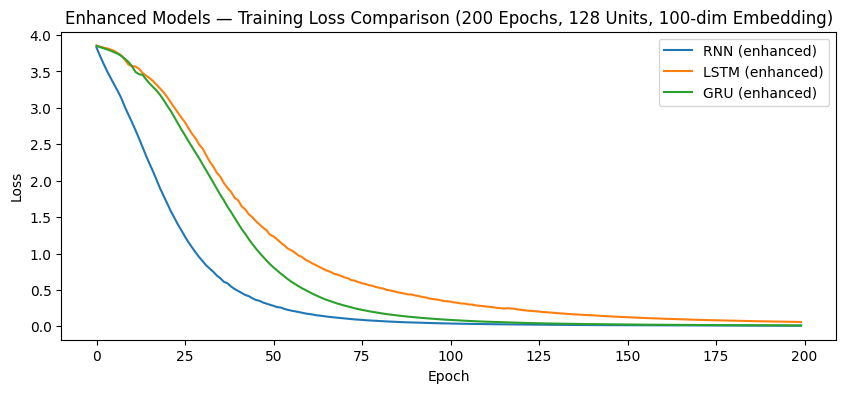

In [15]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['loss'], label='RNN (enhanced)')
plt.plot(lstm_history2.history['loss'], label='LSTM (enhanced)')
plt.plot(gru_history2.history['loss'], label='GRU (enhanced)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Enhanced Models — Training Loss Comparison (200 Epochs, 128 Units, 100-dim Embedding)")
plt.legend()
plt.show()

## ✍️ Task 5 — Generate 10 Words Instead of 5
The original `generate_text` hard-codes the global `tokenizer` and `max_len`, which only works for the baseline corpus. Since we now have a **second** tokenizer and sequence length for `custom_corpus`, we generalize the function to accept any tokenizer and `max_len`, then call it asking for **10 words** instead of 5.

In [16]:
def generate_text_v2(model, tokenizer_obj, max_length, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer_obj.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_length-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer_obj.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

seed = "the solar system"
print("RNN  (enhanced, 10 words):", generate_text_v2(rnn_model2, tokenizer2, max_len2, seed, 10))
print("LSTM (enhanced, 10 words):", generate_text_v2(lstm_model2, tokenizer2, max_len2, seed, 10))
print("GRU  (enhanced, 10 words):", generate_text_v2(gru_model2, tokenizer2, max_len2, seed, 10))

RNN  (enhanced, 10 words): the solar system contains eight planets orbiting the sun planet due many iron


LSTM (enhanced, 10 words): the solar system contains eight planets orbiting the sun sun sun sun sun


GRU  (enhanced, 10 words): the solar system contains eight planets orbiting the sun sun sun sun sun


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**